In [1]:
%config InlineBackend.figure_formats = ['svg']
import pandas as pd
import seaborn as sns
from glob import glob
sns.set_theme(style="ticks", font="Linux Biolinum O", font_scale=1.2)

frames = [pd.read_csv(data) for data in glob('../put-get_*.csv')]
data = pd.concat(frames, ignore_index=True)
data["outer_coding"] = list(zip(data["chunk_n"], data["chunk_k"]))
data["inner_coding"] = list(zip(data["fragment_n"], data["fragment_k"]))

def operation(row):
    return f'{row["protocol"].capitalize()} - {row["op"]}'.replace("Entropy", "Vault")

data["Operation"] = data.apply(operation, axis=1)
data

,protocol,chunk_k,chunk_n,fragment_k,fragment_n,op,latency,outer_coding,inner_coding,Operation
0,entropy,8,10,16,40,put,45.527370,"(10, 8)","(40, 16)",Vault - put
1,entropy,8,10,16,40,slow_get,33.322044,"(10, 8)","(40, 16)",Vault - slow_get
2,entropy,8,10,16,40,put,45.639336,"(10, 8)","(40, 16)",Vault - put
3,entropy,8,10,16,40,slow_get,38.055176,"(10, 8)","(40, 16)",Vault - slow_get
4,entropy,8,10,16,40,put,46.283592,"(10, 8)","(40, 16)",Vault - put
...,...,...,...,...,...,...,...,...,...,...
231,entropy,8,10,32,80,get,14.823833,"(10, 8)","(80, 32)",Vault - get
232,entropy,8,10,32,80,put,65.826680,"(10, 8)","(80, 32)",Vault - put
233,entropy,8,10,32,80,get,14.109310,"(10, 8)","(80, 32)",Vault - get
234,entropy,8,10,32,80,put,63.667442,"(10, 8)","(80, 32)",Vault - put


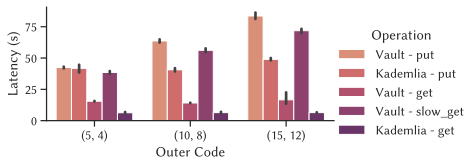

In [2]:
palette = sns.color_palette('flare', n_colors=5)
sns.catplot(data=data[data["inner_coding"] == (80, 32)], 
    kind="bar",
    x="outer_coding", y="latency", hue="Operation",
    order=[(5, 4), (10, 8), (15, 12)],
    hue_order=["Vault - put", "Kademlia - put", "Vault - get", "Vault - slow_get", "Kademlia - get"],
    palette="flare",
    height=2.56, aspect=2.) \
.set_xlabels("Outer Code") \
.set_ylabels("Latency (s)") \
.savefig("../../graphs/put-get-outer.pdf")

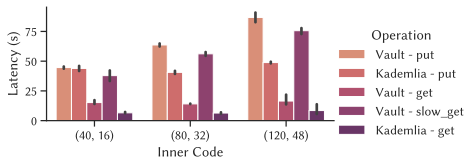

In [3]:
palette = sns.color_palette('flare', n_colors=5)
sns.catplot(data=data[data["outer_coding"] == (10, 8)], 
    kind="bar",
    x="inner_coding", y="latency", hue="Operation",
    order=[(40, 16), (80, 32), (120, 48)],
    hue_order=["Vault - put", "Kademlia - put", "Vault - get", "Vault - slow_get", "Kademlia - get"],
    palette="flare",
    height=2.56, aspect=2.) \
.set_xlabels("Inner Code") \
.set_ylabels("Latency (s)") \
.savefig("../../graphs/put-get-inner.pdf")